# OpenGVLab/InternViT-300M-448px

In [1]:
import torch
from transformers import AutoImageProcessor, AutoTokenizer
from vl_code_for_copy.modeling_internvl_chat import InternVLChatModel
from vl_code_for_copy.tokenization_internlm2 import InternLM2Tokenizer

/home/jovyan/.mlspace/envs/interpretation_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


FlashAttention2 is not installed.


/home/jovyan/.mlspace/envs/interpretation_env/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


# Loading the model

In [2]:
device = 'cuda:0'
vision_model_name = 'OpenGVLab/Mini-InternVL-Chat-2B-V1-5'
vision_weights_dir = '../weights'
tokenizer = AutoTokenizer.from_pretrained(vision_model_name, cache_dir=vision_weights_dir, trust_remote_code=True, use_fast=False)
llm = InternVLChatModel.from_pretrained(
    vision_model_name, 
    cache_dir=vision_weights_dir,
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=True).eval().cuda()

InternLM2ForCausalLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly overwritten. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.


# Functions for image processing and getting features

In [3]:
import numpy as np
import torch
import torchvision.transforms as T
from PIL import Image
from torchvision.transforms.functional import InterpolationMode
from transformers import AutoModel, AutoTokenizer

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

def build_transform(input_size):
    MEAN, STD = IMAGENET_MEAN, IMAGENET_STD
    transform = T.Compose([
        T.Lambda(lambda img: img.convert('RGB') if img.mode != 'RGB' else img),
        T.Resize((input_size, input_size), interpolation=InterpolationMode.BICUBIC),
        T.ToTensor(),
        T.Normalize(mean=MEAN, std=STD)
    ])
    return transform

def find_closest_aspect_ratio(aspect_ratio, target_ratios, width, height, image_size):
    best_ratio_diff = float('inf')
    best_ratio = (1, 1)
    area = width * height
    for ratio in target_ratios:
        target_aspect_ratio = ratio[0] / ratio[1]
        ratio_diff = abs(aspect_ratio - target_aspect_ratio)
        if ratio_diff < best_ratio_diff:
            best_ratio_diff = ratio_diff
            best_ratio = ratio
        elif ratio_diff == best_ratio_diff:
            if area > 0.5 * image_size * image_size * ratio[0] * ratio[1]:
                best_ratio = ratio
    return best_ratio

def dynamic_preprocess(image, min_num=1, max_num=12, image_size=448, use_thumbnail=False):
    orig_width, orig_height = image.size
    aspect_ratio = orig_width / orig_height

    # calculate the existing image aspect ratio
    target_ratios = set(
        (i, j) for n in range(min_num, max_num + 1) for i in range(1, n + 1) for j in range(1, n + 1) if
        i * j <= max_num and i * j >= min_num)
    target_ratios = sorted(target_ratios, key=lambda x: x[0] * x[1])

    # find the closest aspect ratio to the target
    target_aspect_ratio = find_closest_aspect_ratio(
        aspect_ratio, target_ratios, orig_width, orig_height, image_size)

    # calculate the target width and height
    target_width = image_size * target_aspect_ratio[0]
    target_height = image_size * target_aspect_ratio[1]
    blocks = target_aspect_ratio[0] * target_aspect_ratio[1]

    # resize the image
    resized_img = image.resize((target_width, target_height))
    processed_images = []
    for i in range(blocks):
        box = (
            (i % (target_width // image_size)) * image_size,
            (i // (target_width // image_size)) * image_size,
            ((i % (target_width // image_size)) + 1) * image_size,
            ((i // (target_width // image_size)) + 1) * image_size
        )
        # split the image
        split_img = resized_img.crop(box)
        processed_images.append(split_img)
    assert len(processed_images) == blocks
    if use_thumbnail and len(processed_images) != 1:
        thumbnail_img = image.resize((image_size, image_size))
        processed_images.append(thumbnail_img)
    return processed_images

def load_image(image_file, input_size=448, max_num=12, use_thumbnail=True):
    image = Image.open(image_file).convert('RGB')
    transform = build_transform(input_size=input_size)
    images = dynamic_preprocess(image, image_size=input_size, use_thumbnail=use_thumbnail, max_num=max_num)
    pixel_values = [transform(image) for image in images]
    pixel_values = torch.stack(pixel_values)
    return pixel_values

def load_from_pil(image, input_size=448, max_num=12, use_thumbnail=True):
    transform = build_transform(input_size=input_size)
    images = dynamic_preprocess(image, image_size=input_size, use_thumbnail=use_thumbnail, max_num=max_num)
    pixel_values = [transform(image) for image in images]
    pixel_values = torch.stack(pixel_values)
    return pixel_values

@torch.no_grad()
def extract_feature(llm, pixel_values):
    if llm.select_layer == -1:
        vit_embeds = llm.vision_model(
            pixel_values=pixel_values,
            output_hidden_states=False,
            return_dict=True).last_hidden_state
    else:
        vit_embeds = llm.vision_model(
            pixel_values=pixel_values,
            output_hidden_states=True,
            return_dict=True).hidden_states[llm.select_layer]
    vit_embeds = vit_embeds[:, 1:, :]

    h = w = int(vit_embeds.shape[1] ** 0.5)
    vit_embeds = vit_embeds.reshape(vit_embeds.shape[0], h, w, -1)
    return vit_embeds

# Generating dataset

In [ ]:
import os
import json
from tqdm import tqdm
from PIL import Image

num_patches_per_side = llm.config.vision_config.image_size // llm.config.vision_config.patch_size

datasets_dir = '../dataset'
mode = 'val' #'bu' #'val' #'train'
batch_size = 16

coco_train_images_path = '<-- write here train coco image path -->'
coco_val_images_path = '<-- write here val coco image path -->'

vision_model_name_for_path = '-'.join(vision_model_name.split('/'))
train_max_images = 200000
train_images_dir = coco_train_images_path # len of train2017 = 115404
train_features_dir = f'{datasets_dir}/{vision_model_name_for_path}/tensors'
train_features_json = f'{datasets_dir}/{vision_model_name_for_path}/map.json'

val_max_images = 100
val_images_dir = coco_val_images_path # len of val2017 = 4515
val_features_dir = f'{datasets_dir}/{vision_model_name_for_path}/tensors_val'
val_features_json = f'{datasets_dir}/{vision_model_name_for_path}/map_val.json'

image_feature_map = {}

if mode == 'train':
    max_images = train_max_images
    images_dir = train_images_dir
    features_dir = train_features_dir
    features_json = train_features_json
    image_names = os.listdir(images_dir)[:max_images]
    os.makedirs(features_dir, mode=0o777, exist_ok=True)
elif mode == 'val':
    max_images = val_max_images
    images_dir = val_images_dir
    features_dir = val_features_dir
    features_json = val_features_json
    image_names = os.listdir(images_dir)[:max_images]
    os.makedirs(features_dir, mode=0o777, exist_ok=True)
else:
    raise Exception

with torch.inference_mode(), torch.no_grad():

    for i in tqdm(range(0, len(image_names), batch_size)):
        batch_image_names = image_names[i:i+batch_size]
        batch_processed_images = []
        batch_image_paths = []
        batch_feature_paths = []

        for image_name in batch_image_names:
            feature_name = image_name.split('.')[0]
            feature_path = os.path.join(features_dir, f'{feature_name}.pt')
            image_path = os.path.join(images_dir, image_name)

            try:
                example = Image.open(image_path).convert('RGB')
                pixel_values = load_from_pil(example, max_num=1)[-1].to(torch.bfloat16)
                batch_processed_images.append(pixel_values)
                batch_image_paths.append(image_path)
                batch_feature_paths.append(feature_path)
            except Exception as e:
                print(f"Error processing image {image_path}: {e}")
                continue # Skip this image if loading/preprocessing fails

        if not batch_processed_images: # If all images in batch failed
            continue

        images_batch = torch.stack(batch_processed_images).to(device)
        batch_features: torch.Tensor = extract_feature(llm, images_batch)

        assert batch_features.dtype == torch.bfloat16
        assert batch_features.shape[0] == len(batch_image_paths) # Check batch size consistency

        # Process and save features for each image in the batch
        for idx in range(batch_features.shape[0]):
            image_path = batch_image_paths[idx]
            feature_path = batch_feature_paths[idx]
            image_feature_map[image_path] = feature_path

            features = batch_features[idx]
            features_reshaped = features.clone()
            torch.save(features_reshaped, feature_path)

    with open(features_json, 'w') as config:
        json.dump(image_feature_map, config)

100%|██████████| 7/7 [00:09<00:00,  1.33s/it]


# Checking that val doesn't contain nonsense.

In [7]:
import json
import numpy as np
import torch.nn.functional as F

from PIL import Image
from torch.utils.data import Dataset

class FeaturesDataset(Dataset):
    def __init__(self, features_json_path, mode='train', side_size=None, image_processor=None):
        with open(features_json_path, 'r') as map_file:
            self.map = list(json.load(map_file).items())
        self.mode = mode

        self.side_size = side_size
        self.image_processor = image_processor

    def __len__(self):
        return len(self.map)

    def __getitem__(self, idx):
        image_path, feature_path = self.map[idx]
        feature = torch.load(feature_path, map_location='cpu').to(torch.float32)
        
        image = Image.open(image_path).convert('RGB')
        processed_image = load_from_pil(image, max_num=1)[0]
        processed_image = torch.tensor(processed_image)
        if processed_image.shape[-1] != side_size:
            interpolated_image = F.interpolate(processed_image[None], 
                                               size=(self.side_size, self.side_size), 
                                               mode='bilinear', align_corners=False)[0]
        else:
            interpolated_image = processed_image
        if self.mode == 'train':
            return interpolated_image, feature.permute(2, 0, 1) # tensor[3 x 224 x 224], tensor[768 x 14 x 14]
        else:
            return np.asarray(image), interpolated_image, feature.permute(2, 0, 1) # array(427, 640, 3), tensor[3 x 224 x 224], tensor[768 x 14 x 14]

features_json_path = '../dataset/OpenGVLab-Mini-InternVL-Chat-2B-V1-5/map_val.json'
side_size=448
val_dataset = FeaturesDataset(features_json_path, 'val', side_size, lambda x: load_from_pil(x, max_num=1))

/tmp/ipykernel_1523186/1718126994.py:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  processed_image = torch.tensor(processed_image)


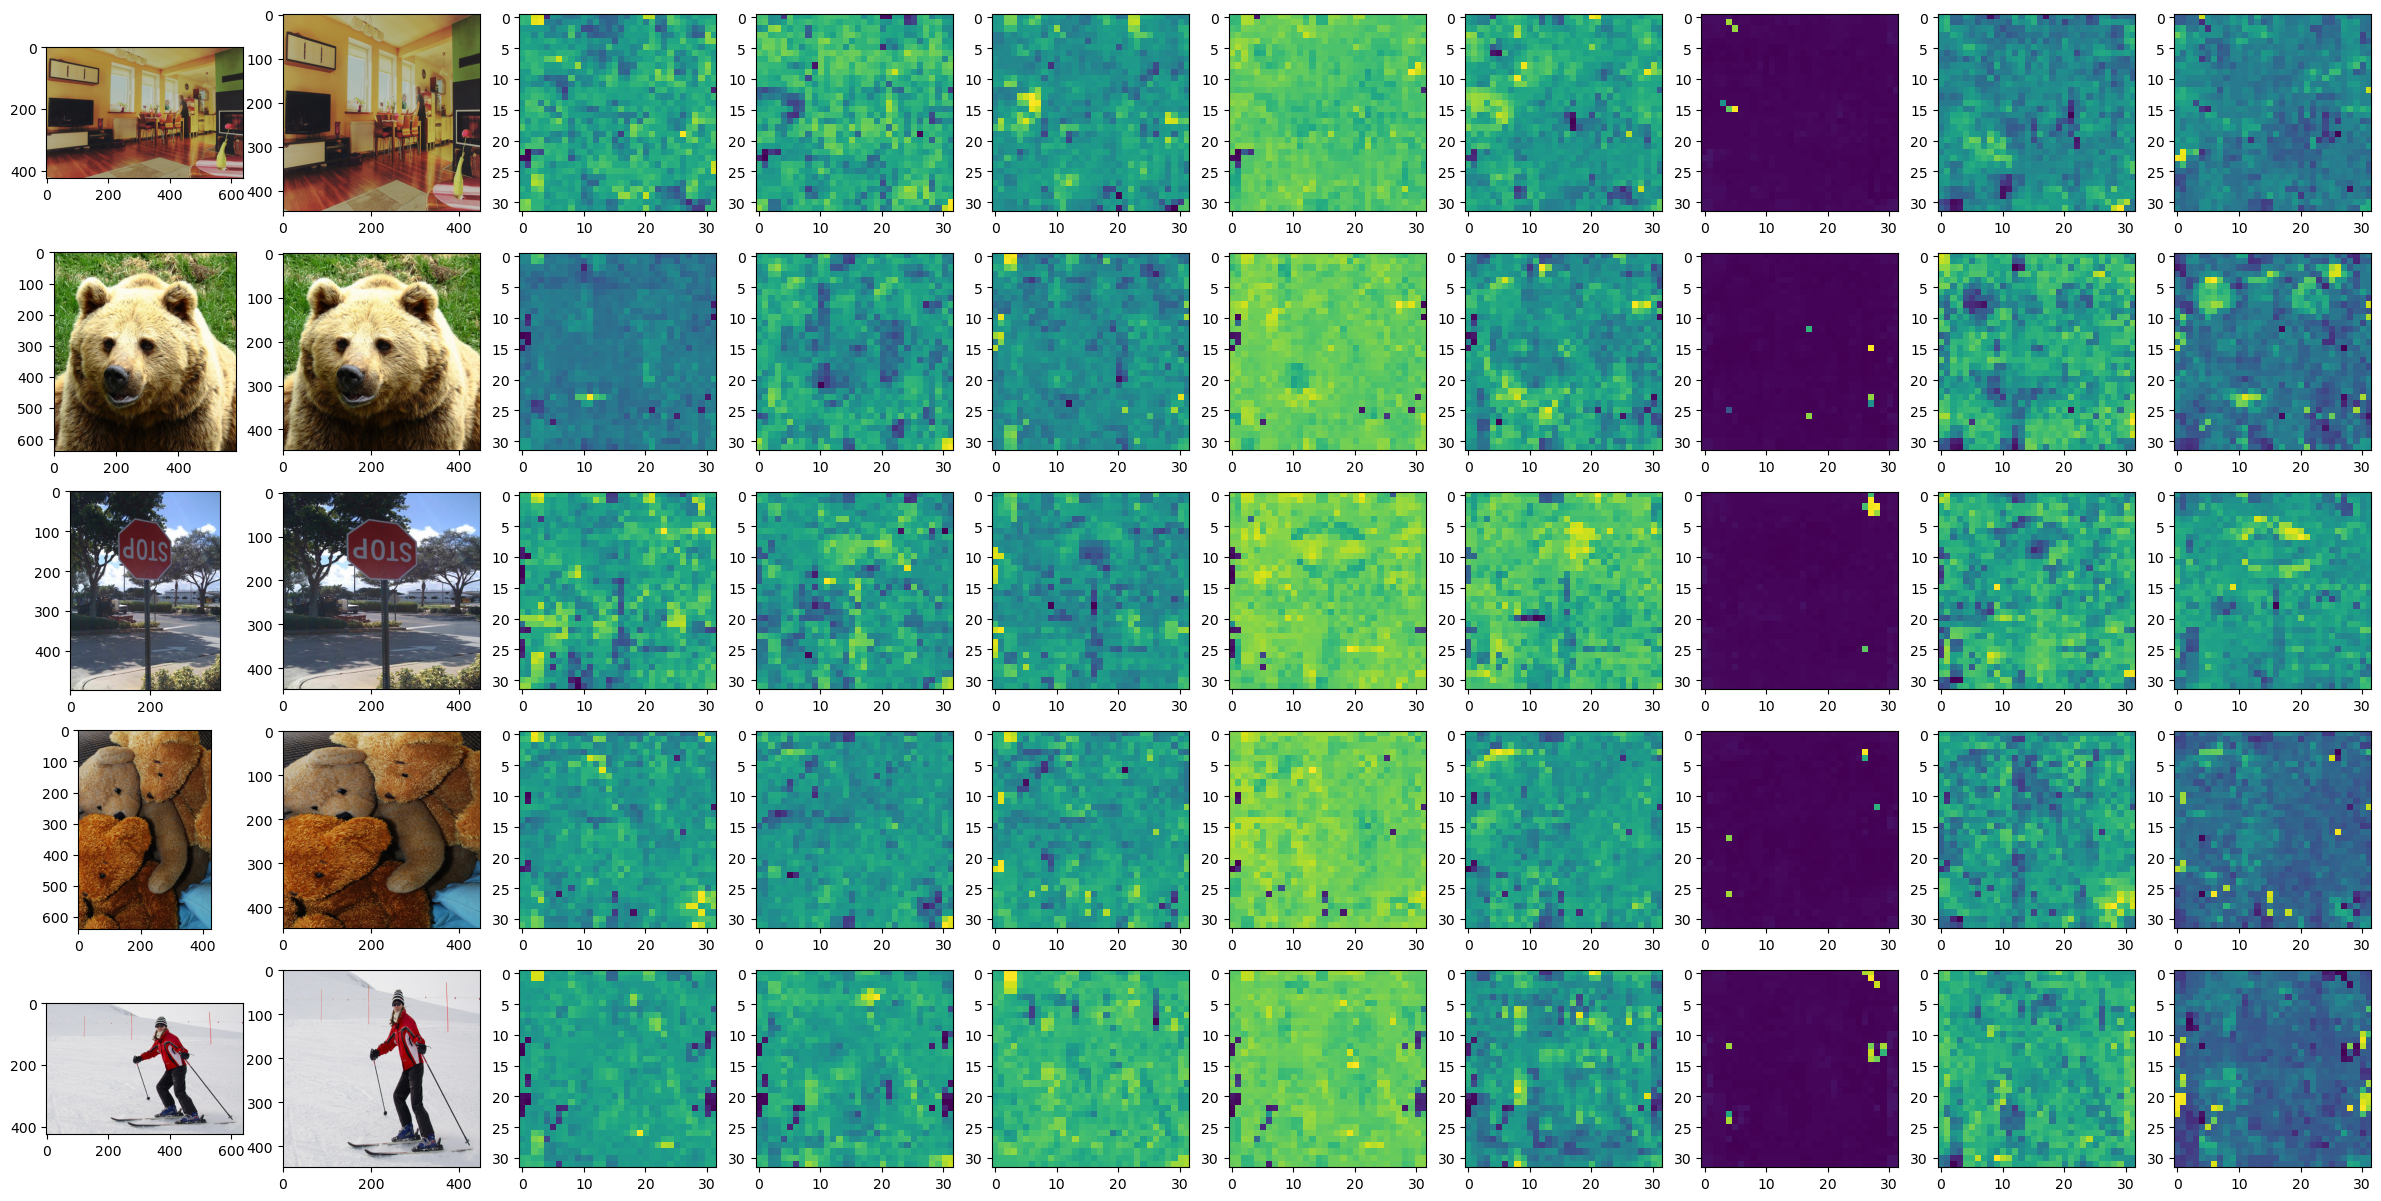

In [8]:
import matplotlib.pyplot as plt

im_mean = torch.as_tensor(IMAGENET_MEAN)
im_std = torch.as_tensor(IMAGENET_STD)

nrows, ncols, scale = 5, 10, 3
fig, axes = plt.subplots(ncols=ncols, nrows=nrows, figsize=(ncols * scale, nrows * scale))

for i in range(nrows):
    im, inter_im, t = val_dataset[i]
    inter_im = inter_im.permute(1, 2, 0)
    inter_im = inter_im * im_std[None, None] + im_mean[None, None]

    axes[i, 0].imshow(im)
    axes[i, 1].imshow(inter_im)
    for j in range(2, ncols):
        axes[i, j].imshow(t[t.shape[0] // (ncols - 2) * (j - 2) + 10])